In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import polars as pl

from ethos.constants import PROJECT_ROOT
from ethos.constants import SpecialToken as ST
from ethos.inference.constants import Reason, Task
from ethos.metrics import compute_and_print_metrics, preprocess_inference_results

results_dir = PROJECT_ROOT / "results"

## ICU Readmission results

In [2]:
def process_icu_admission_results(input_dir, outcome_tokens, **kwargs) -> pl.DataFrame:
    return preprocess_inference_results(
        input_dir,
        actual_expr=pl.col("actual").is_in(outcome_tokens),
        expected_expr=pl.col("expected").is_in(outcome_tokens),
        filter_ambiguous=pl.col("stop_reason") == Reason.GOT_TOKEN,
        **kwargs,
    )

2026-09-18 16:41:14.001 | WARNING  | ethos.metrics:preprocess_inference_results:319 - Dropped 4 (0.03%) ambiguous results.
/home/henri/ethos-benchmark/src/ethos/metrics.py:172: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  precision_values = np.divide(tpr_values * positives, denominator, where=more_than_zero)


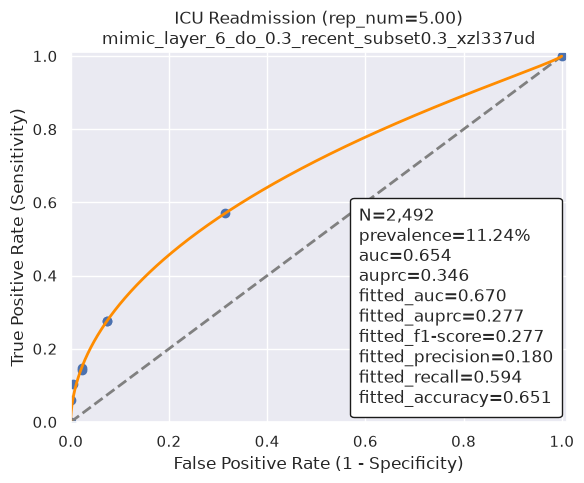

In [3]:
icu_admission_results = []
for input_dir in (results_dir / Task.ICU_READMISSION).iterdir():
    # df = process_icu_admission_results(input_dir, outcome_tokens=[ST.DEATH, ST.ICU_ADMISSION])
    df = process_icu_admission_results(input_dir, outcome_tokens=[ST.ICU_ADMISSION])

    rep_num = df["counts"].mean()
    res = compute_and_print_metrics(
        df["expected"],
        df["actual"],
        f"ICU Readmission (rep_num={rep_num:.2f})\n{input_dir.name}",
    )
    icu_admission_results.append(
        {
            "name": input_dir.name,
            "auc": res["fitted_auc"],
            "rep_num": rep_num,
        }
    )
    plt.show()
icu_admission_results = pl.DataFrame(icu_admission_results).sort("auc", descending=True)

In [ ]:
icu_admission_results